<a href="https://colab.research.google.com/github/rupakdey94/EV-Adoption-Analysis/blob/main/Healthcare_patients_data_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
df = pd.read_csv('/content/healthcare_patients.xls')

In [ ]:
print("\n--- Dataset Summary Info ---")
print(df.info())

print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

# Basic stats for numerical dimensions
print("\n--- Statistical Overview ---")
print(df.describe())



--- Dataset Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1000 non-null   object 
 1   age                       1000 non-null   int64  
 2   gender                    1000 non-null   object 
 3   admission_type            1000 non-null   object 
 4   primary_diagnosis         1000 non-null   object 
 5   num_lab_procedures        941 non-null    float64
 6   num_medications           1000 non-null   int64  
 7   time_in_hospital          1000 non-null   int64  
 8   has_diabetes              1000 non-null   int64  
 9   has_hypertension          1000 non-null   int64  
 10  discharge_disposition_id  1000 non-null   int64  
 11  readmitted_days           1000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 93.9+ KB
None

--- Missing Value Counts 

/tmp/ipykernel_1024/187455397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_readmitted', data=df, palette='Set2')


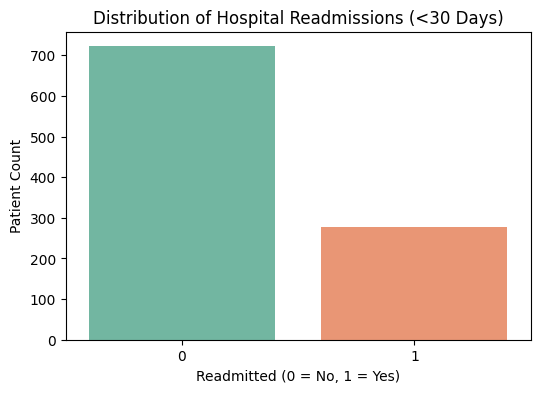

In [ ]:
# Create target variable: 1 if readmitted within 30 days, else 0
df['is_readmitted'] = df['readmitted_days'].apply(lambda x: 1 if x <= 30 else 0)

# Drop raw tracking columns not useful for baseline prediction
df = df.drop(columns=['patient_id', 'readmitted_days'])

# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_readmitted', data=df, palette='Set2')
plt.title('Distribution of Hospital Readmissions (<30 Days)')
plt.xlabel('Readmitted (0 = No, 1 = Yes)')
plt.ylabel('Patient Count')
plt.show()


In [ ]:
# Define features and target
X = df.drop(columns=['is_readmitted'])
y = df['is_readmitted']

# Split columns by data type
numerical_cols = ['age', 'num_lab_procedures', 'num_medications', 'time_in_hospital']
categorical_cols = ['gender', 'admission_type', 'primary_diagnosis']
passthrough_cols = ['has_diabetes', 'has_hypertension', 'discharge_disposition_id']

# Preprocessing for numerical data: Impute missing with median, scale features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data: Impute missing if any, apply One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing transformers together
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('pass', 'passthrough', passthrough_cols)
    ])

print("Preprocessing pipelines successfully created.")


Preprocessing pipelines successfully created.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create a master training pipeline with the classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Train the model
model_pipeline.fit(X_train, y_train)
print("Random Forest Classifier model training complete!")


Random Forest Classifier model training complete!



--- Model Evaluation Classification Report ---
              precision    recall  f1-score   support

           0       0.72      0.97      0.83       144
           1       0.38      0.05      0.09        56

    accuracy                           0.71       200
   macro avg       0.55      0.51      0.46       200
weighted avg       0.63      0.71      0.62       200

ROC-AUC Performance Score: 0.5379


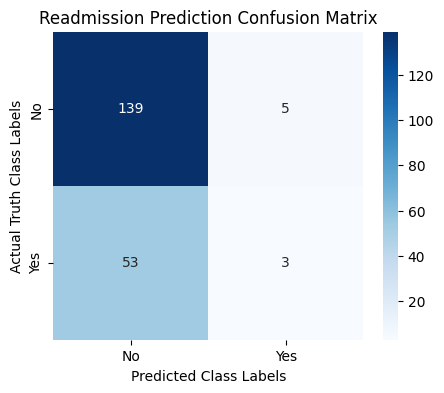

In [ ]:
# Generate predictions
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Display standard metrics
print("\n--- Model Evaluation Classification Report ---")
print(classification_report(y_test, y_pred))

# Calculate ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Performance Score: {roc_auc:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Readmission Prediction Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('Actual Truth Class Labels')
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Extract the base pipeline structure we created earlier
# We will tune the 'classifier' step inside the pipeline
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

# Setup 5-Fold Cross Validation targeting the ROC-AUC score metric
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to find the optimal settings
print("--- Starting Hyperparameter Tuning Grid Search ---")
grid_search.fit(X_train, y_train)

print(f"\nBest Cross-Validation Score (ROC-AUC): {grid_search.best_score_:.4f}")
print("Best Parameter Mix Identified:", grid_search.best_params_)

# Assign the optimized model as our new active model pipeline
best_model_pipeline = grid_search.best_estimator_

--- Starting Hyperparameter Tuning Grid Search ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Cross-Validation Score (ROC-AUC): 0.4973
Best Parameter Mix Identified: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}


/tmp/ipykernel_1024/1808256636.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


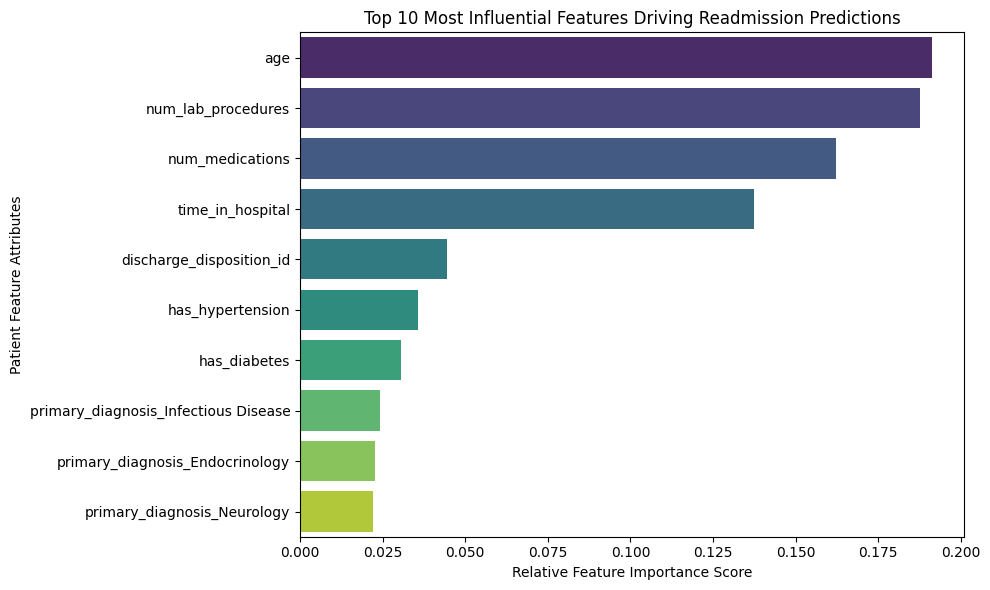


--- Feature Importance Ranking List ---
                             Feature  Importance
                                 age    0.191382
                  num_lab_procedures    0.187500
                     num_medications    0.162151
                    time_in_hospital    0.137522
            discharge_disposition_id    0.044407
                    has_hypertension    0.035743
                        has_diabetes    0.030475
primary_diagnosis_Infectious Disease    0.024199
     primary_diagnosis_Endocrinology    0.022831
         primary_diagnosis_Neurology    0.022072
             admission_type_Elective    0.021896
                       gender_Female    0.021525
                         gender_Male    0.021196
            admission_type_Emergency    0.020967
        primary_diagnosis_Cardiology    0.020619
  primary_diagnosis_Gastroenterology    0.018401
               admission_type_Urgent    0.017116


In [ ]:
# Extract the trained preprocessor step from our optimized pipeline
trained_preprocessor = best_model_pipeline.named_steps['preprocessor']

# Retrieve modified categorical column names from the Hot Encoder step
encoded_cat_cols = trained_preprocessor.named_transformers_['cat']\
                                       .named_steps['onehot']\
                                       .get_feature_names_out(categorical_cols).tolist()

# Reconstruct the exact order of the columns as they exited the preprocessor pipeline
all_feature_names = numerical_cols + encoded_cat_cols + passthrough_cols

# Extract individual feature importance weight metrics from the Random Forest step
importances = best_model_pipeline.named_steps['classifier'].feature_importances_

# Structure the findings inside a neat DataFrame
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Render the Importance Visualization Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Influential Features Driving Readmission Predictions')
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Patient Feature Attributes')
plt.tight_layout()
plt.show()

# Print out the calculated ranked matrix list
print("\n--- Feature Importance Ranking List ---")
print(importance_df.to_string(index=False))


In [ ]:
# Mock profile matching the exact raw columns of the input file
new_patient = pd.DataFrame([{
    'age': 72,
    'gender': 'Female',
    'admission_type': 'Emergency',
    'primary_diagnosis': 'Neurology',
    'num_lab_procedures': 45.0,
    'num_medications': 28,
    'time_in_hospital': 8,
    'has_diabetes': 1,
    'has_hypertension': 1,
    'discharge_disposition_id': 3
}])

# Predict outcome directly using the end-to-end best model pipeline
prediction = best_model_pipeline.predict(new_patient)
probability = best_model_pipeline.predict_proba(new_patient)[:, 1]

print("\n--- Live Patient Risk Profiler Prediction ---")
print(f"Readmission Probability: {probability[0]*100:.2f}%")
print(f"Prediction: {'High Risk - Will Readmit within 30 Days' if prediction[0] == 1 else 'Low Risk - Unlikely to Readmit'}")



--- Live Patient Risk Profiler Prediction ---
Readmission Probability: 8.00%
Prediction: Low Risk - Unlikely to Readmit


In [ ]:
pip install shap joblib


In [ ]:
import joblib

# Define the file name to store the artifact
model_filename = 'optimized_readmission_model.pkl'

# Export and serialize the entire pipeline architecture
joblib.dump(best_model_pipeline, model_filename)
print(f"--- Production model successfully saved to: {model_filename} ---")

# --- SIMULATE LOADING IT IN A NEW SCRIPT ---
# Load the model directly from the saved file binary
loaded_pipeline = joblib.load(model_filename)
print("Saved model file successfully loaded and verified ready for deployment!")


--- Production model successfully saved to: optimized_readmission_model.pkl ---
Saved model file successfully loaded and verified ready for deployment!


In [ ]:
import shap

# 1. Isolate the final classifier model and preprocessor steps from our pipeline
trained_preprocessor = best_model_pipeline.named_steps['preprocessor']
classifier_model = best_model_pipeline.named_steps['classifier']

# 2. Transform the raw test data into the numeric matrix the classifier reads
X_test_transformed = trained_preprocessor.transform(X_test)

# Convert the array back to a clean DataFrame matching our step 8 names
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# 3. Initialize the SHAP TreeExplainer designed for Random Forests
explainer = shap.TreeExplainer(classifier_model)

# Calculate SHAP impact scores for the test set observations
# We extract index [1] to capture the probability scores for readmission (Class 1)
shap_values = explainer.shap_values(X_test_df)

# If shape tracking returns a multi-dimensional array list, index the second array layer
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

print("--- SHAP calculations computed successfully ---")


--- SHAP calculations computed successfully ---


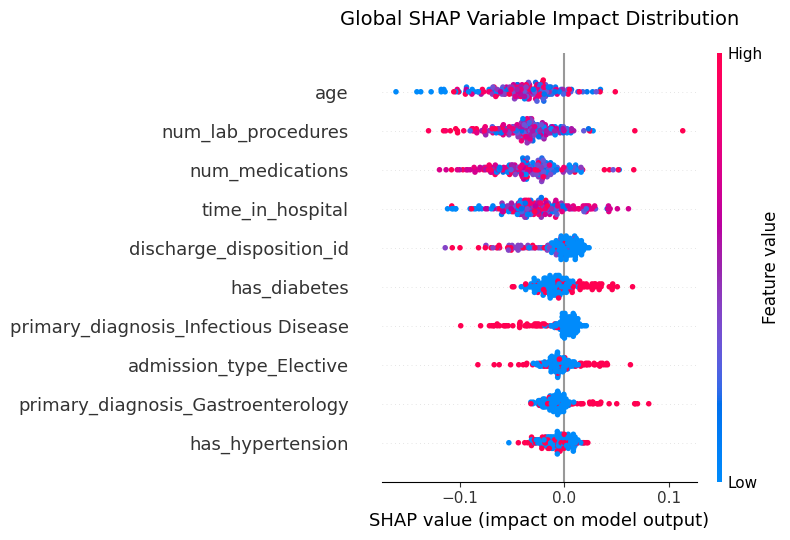

In [ ]:
# Render the Global Summary Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test_df, max_display=10, show=False)
plt.title('Global SHAP Variable Impact Distribution', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


<Figure size 1200x400 with 0 Axes>

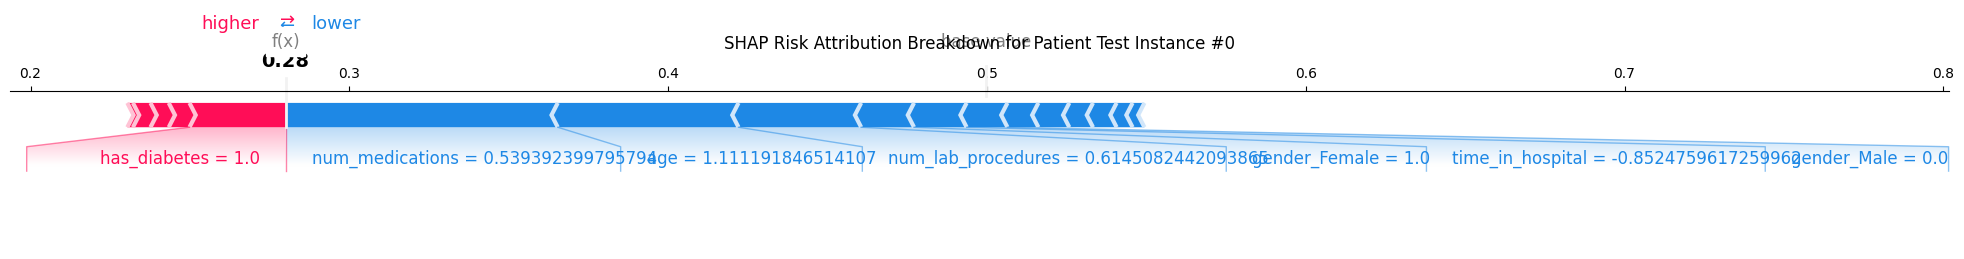

In [ ]:
# Select an arbitrary individual profile from the validation set (e.g., patient index 0)
patient_index = 0

# Initialize JS visualization environment required for clear SHAP local layouts
shap.initjs()

# Render local structural explanation plot
plt.figure(figsize=(12, 4))
shap.plots.force(
    explainer.expected_value[1],
    shap_values_to_plot[patient_index],
    X_test_df.iloc[patient_index],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Risk Attribution Breakdown for Patient Test Instance #{patient_index}', fontsize=12, pad=30)
plt.tight_layout()
plt.show()


In [ ]:
pip install streamlit xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import joblib

# 1. Load the pre-trained, production-ready model pipeline
@st.cache_resource
def load_model():
    return joblib.load('optimized_readmission_model.pkl')

model = load_model()

# 2. Setup the Web Dashboard Title UI Layout
st.set_page_config(page_title="Clinical Readmission Predictor", layout="centered")
st.title("🏥 Patient Readmission Risk Profiler")
st.markdown("Enter patient metrics below to evaluate the probability of short-term hospital readmission (within 30 days).")

st.sidebar.header("Demographics & Diagnostic Metrics")

# 3. Create input handles for user fields matching the base CSV structures
age = st.sidebar.slider("Patient Age", min_value=0, max_value=120, value=55)
gender = st.sidebar.selectbox("Gender", options=["Male", "Female"])
admission_type = st.sidebar.selectbox("Admission Type", options=["Emergency", "Elective", "Urgent"])
primary_diagnosis = st.sidebar.selectbox("Primary Diagnosis", options=["Cardiology", "Neurology", "Endocrinology", "Gastroenterology", "Infectious Disease"])

st.sidebar.header("Clinical Activity Metrics")
num_lab_procedures = st.sidebar.number_input("Number of Lab Procedures Done", min_value=0.0, max_value=200.0, value=45.0)
num_medications = st.sidebar.slider("Number of Prescribed Medications", min_value=1, max_value=100, value=15)
time_in_hospital = st.sidebar.slider("Time in Hospital (Days)", min_value=1, max_value=30, value=5)

st.sidebar.header("Comorbidities & Discharge Logistics")
has_diabetes = st.sidebar.checkbox("Patient has History of Diabetes?", value=False)
has_hypertension = st.sidebar.checkbox("Patient has History of Hypertension?", value=False)
discharge_disposition_id = st.sidebar.number_input("Discharge Disposition ID Status Code", min_value=1, max_value=30, value=1)

# 4. Process real-time prediction calculations upon form submission click
if st.button("Evaluate Patient Profile Risk Status"):
    # Reconstruct inputs into a raw structure matching the baseline dataset expectations
    input_data = pd.DataFrame([{
        'age': age,
        'gender': gender,
        'admission_type': admission_type,
        'primary_diagnosis': primary_diagnosis,
        'num_lab_procedures': num_lab_procedures,
        'num_medications': num_medications,
        'time_in_hospital': time_in_hospital,
        'has_diabetes': 1 if has_diabetes else 0,
        'has_hypertension': 1 if has_hypertension else 0,
        'discharge_disposition_id': discharge_disposition_id
    }])

    # Calculate inference values using the complete production model pipeline
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    # Render final status display blocks based on output criteria
    st.subheader("--- Clinical Risk Report Output ---")
    st.metric(label="Calculated Readmission Probability Score", value=f"{probability * 100:.2f}%")

    if prediction == 1:
        st.error("🚨 **High Risk Alert:** The profile matches short-term readmission patterns. Consider post-discharge intervention strategies.")
    else:
        st.success("✅ **Standard Risk Profile:** The patient falls below the baseline critical threat risk matrix thresholds.")


2026-09-22 05:05:23.118 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 05:05:23.208 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 05:05:23.211 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 05:05:23.953 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-22 05:05:23.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 05:05:23.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-22 05:05:23.959 Thread 'MainThread'

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize an XGBoost classifier configured for imbalanced data targets
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=1.0,  # Adjust if class balance changes significantly
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Swap the final classification node step within a matching production preprocessing pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# 3. Fit the machine learning architecture directly onto the training sets
print("--- Training Advanced Extreme Gradient Boosting (XGBoost) Model ---")
xgb_pipeline.fit(X_train, y_train)

# 4. Generate predictions and cross-validate against validation data matrices
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- XGBoost Classification Performance Metric Summary ---")
print(classification_report(y_test, xgb_pred))
print(f"XGBoost Model Final Validation ROC-AUC Score: {roc_auc_score(y_test, xgb_prob):.4f}")


--- Training Advanced Extreme Gradient Boosting (XGBoost) Model ---


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [05:06:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Classification Performance Metric Summary ---
              precision    recall  f1-score   support

           0       0.72      0.88      0.79       144
           1       0.31      0.14      0.20        56

    accuracy                           0.67       200
   macro avg       0.52      0.51      0.49       200
weighted avg       0.61      0.67      0.63       200

XGBoost Model Final Validation ROC-AUC Score: 0.5188


--- Running 5-Fold Cross-Validation Matrix ---


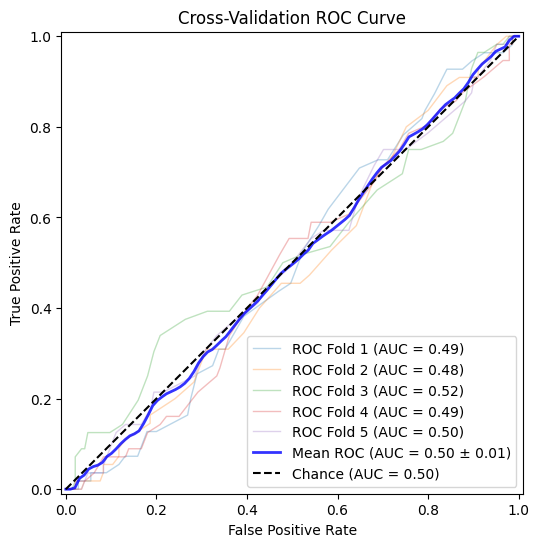

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.pyplot as plt
import numpy as np

# Initialize cross-validation splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

print("--- Running 5-Fold Cross-Validation Matrix ---")
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    # Slice the cross-validation folds
    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

    # Fit the existing pipeline structure on this fold
    model_pipeline.fit(X_fold_train, y_fold_train)

    # Plot the ROC curve for the current fold
    viz = RocCurveDisplay.from_estimator(
        model_pipeline, X_fold_val, y_fold_val,
        name=f"ROC Fold {fold + 1}", alpha=0.3, lw=1, ax=ax
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

# Plot Mean ROC Performance Line
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(
    mean_fpr, mean_tpr, color="b",
    label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})", lw=2, alpha=0.8
)

# Plot Random Guess baseline line
ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="Cross-Validation ROC Curve")
ax.legend(loc="lower right")
plt.show()


In [ ]:
import pandas as pd
import joblib
from datetime import datetime

def process_new_patient_batch(input_csv_path, output_csv_path):
    """
    Cleans incoming batch data files, passes them through the inference pipeline,
    and saves calculated high/low risk evaluations to a timestamped file.
    """
    print(f"--- Loading New Patient Batch: {input_csv_path} ---")
    new_data = pd.read_csv(input_csv_path)

    # Preserve IDs for structural tracking output
    patient_ids = new_data['patient_id']

    # Align incoming columns with features the model expects
    features_to_keep = [
        'age', 'gender', 'admission_type', 'primary_diagnosis',
        'num_lab_procedures', 'num_medications', 'time_in_hospital',
        'has_diabetes', 'has_hypertension', 'discharge_disposition_id'
    ]
    X_batch = new_data[features_to_keep]

    # Load your validated deployment artifact file
    model = joblib.load('optimized_readmission_model.pkl')

    # Run absolute inference matrix predictions
    predictions = model.predict(X_batch)
    probabilities = model.predict_proba(X_batch)[:, 1]

    # Synthesize results into an actionable dashboard export sheet
    output_df = pd.DataFrame({
        'patient_id': patient_ids,
        'readmission_risk_score': probabilities,
        'predicted_flag': predictions,
        'processed_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    })

    output_df.to_csv(output_csv_path, index=False)
    print(f"Inference complete! Exported scored profiles safely to: {output_csv_path}")

# Example execution usage handle:
# process_new_patient_batch('incoming_patients_monday.csv', 'scored_patients_monday.csv')


In [ ]:
import pytest
import pandas as pd
import numpy as np

# Mock dataset resembling your baseline file constraints for unit check testing
@pytest.fixture
def sample_raw_data():
    return pd.DataFrame({
        'patient_id': ['PT99999'],
        'age': [50],
        'gender': ['Male'],
        'admission_type': ['Emergency'],
        'primary_diagnosis': ['Cardiology'],
        'num_lab_procedures': [45.0],
        'num_medications': [10],
        'time_in_hospital': [5],
        'has_diabetes': [0],
        'has_hypertension': [1],
        'discharge_disposition_id': [1],
        'readmitted_days': [20]
    })

def test_target_variable_generation(sample_raw_data):
    """Verify target logic maps metrics correctly beneath critical threshold rules."""
    # Run the exact code block mapping from Step 3
    sample_raw_data['is_readmitted'] = sample_raw_data['readmitted_days'].apply(lambda x: 1 if x <= 30 else 0)

    assert sample_raw_data['is_readmitted'].iloc[0] == 1
    assert 'is_readmitted' in sample_raw_data.columns

def test_missing_column_vulnerability(sample_raw_data):
    """Ensure essential pipeline calculation inputs contain zero name key changes."""
    required_features = ['age', 'gender', 'admission_type', 'primary_diagnosis', 'num_medications']

    for feature in required_features:
        assert feature in sample_raw_data.columns, f"Critical input validation breakdown: '{feature}' missing."

def test_numerical_bounds(sample_raw_data):
    """Ensure column values do not contain logically impossible numbers."""
    assert sample_raw_data['age'].min() >= 0, "Data Integrity Error: Negative age detected."
    assert sample_raw_data['time_in_hospital'].iloc[0] > 0, "Data Integrity Error: Stay duration must be > 0."

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Transform raw matrices into numeric vectors using our existing preprocessor
X_train_transformed = trained_preprocessor.transform(X_train)
X_test_transformed = trained_preprocessor.transform(X_test)

# Convert arrays into PyTorch Float Tensors
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create highly efficient DataLoaders for batch management
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# 2. Design the Network Architecture
class ReadmissionNN(nn.Module):
    def __init__(self, input_dim):
        super(ReadmissionNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 32)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(32, 16)
        self.output_layer = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

# Instantiate model, loss function, and optimizer
input_dim = X_train_transformed.shape[1]
nn_model = ReadmissionNN(input_dim)
criterion = nn.BCELoss() # Binary Cross-Entropy for class targets
optimizer = optim.Adam(nn_model.parameters(), lr=0.005)

# 3. Model Training Loop
print("--- Training PyTorch Deep Learning Classifier ---")
nn_model.train()
for epoch in range(20): # Train for 20 complete iterations
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = nn_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/20 | Batch Processing Loss: {loss.item():.4f}")

# Save PyTorch neural weights structural file state
torch.save(nn_model.state_dict(), 'nn_readmission_weights.pth')
print("Deep Learning model weights exported safely!")

--- Training PyTorch Deep Learning Classifier ---
Epoch 5/20 | Batch Processing Loss: 0.7196
Epoch 10/20 | Batch Processing Loss: 0.5586
Epoch 15/20 | Batch Processing Loss: 0.6415
Epoch 20/20 | Batch Processing Loss: 0.5242
Deep Learning model weights exported safely!


In [ ]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import joblib

# 1. Initialize FastAPI Server Instance application app
app = FastAPI(
    title="Clinical Inference API Engine",
    description="Production-grade REST microservice to predict patient readmissions.",
    version="1.0"
)

# Load your validated end-to-end best pipeline model mapping artifact
model_pipeline = joblib.load('optimized_readmission_model.pkl')

# 2. Define Schema to enforce strict JSON input types validation rules
class PatientProfile(BaseModel):
    age: int
    gender: str
    admission_type: str
    primary_diagnosis: str
    num_lab_procedures: float
    num_medications: int
    time_in_hospital: int
    has_diabetes: int
    has_hypertension: int
    discharge_disposition_id: int

@app.get("/")
def home():
    return {"status": "Online", "service": "Patient Readmission Core Engine API"}

# 3. Post Route endpoint to process patient diagnostic metrics evaluations
@app.post("/predict")
def predict_readmission(patient: PatientProfile):
    try:
        # Convert incoming JSON dictionary seamlessly into standard DataFrame shape
        patient_df = pd.DataFrame([patient.dict()])

        # Calculate evaluation scores using our deployment asset model system
        prediction = int(model_pipeline.predict(patient_df)[0])
        probability = float(model_pipeline.predict_proba(patient_df)[0][1])

        # Return standardized system response payload
        return {
            "readmission_risk_score": round(probability, 4),
            "high_risk_flag": True if prediction == 1 else False,
            "clinical_recommendation": "Flag profile for transitional care." if prediction == 1 else "Standard discharge."
        }

    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Inference Pipeline Error: {str(e)}")


# New Section